In [2]:
import numpy as np
import pandas as pd

# Generating data

y = (x * z)³

In [3]:
x_data = np.random.uniform(low=0, high=1.0, size=(3000,))
#z_data = np.random.standard_normal(size=(3000,))
z_data = np.random.uniform(low=0, high=1.0, size=(3000,))
pow_data = np.power(x_data * z_data, 1)
multi_data = x_data * z_data

df_power = pd.DataFrame(np.array([x_data, z_data, pow_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_multi = pd.DataFrame(np.array([x_data, z_data, multi_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_power

,x_data,z_data,y_data
0,0.834687,0.592787,0.494791
1,0.713088,0.357820,0.255158
2,0.301078,0.943712,0.284131
3,0.071402,0.326410,0.023306
4,0.336740,0.497622,0.167569
...,...,...,...
2995,0.650550,0.171474,0.111552
2996,0.193103,0.629087,0.121479
2997,0.907156,0.502516,0.455860
2998,0.527683,0.361076,0.190534


In [4]:
df_multi

,x_data,z_data,y_data
0,0.834687,0.592787,0.494791
1,0.713088,0.357820,0.255158
2,0.301078,0.943712,0.284131
3,0.071402,0.326410,0.023306
4,0.336740,0.497622,0.167569
...,...,...,...
2995,0.650550,0.171474,0.111552
2996,0.193103,0.629087,0.121479
2997,0.907156,0.502516,0.455860
2998,0.527683,0.361076,0.190534


In [2]:
import spice_net as spn

#spn.approximate_local_min(-4, 4, eps=0.05, t=0.005, function=lambda x: (x - 3) ** 2)
spn.approximate_local_min_axenie(-4, -1, tolerance=abs((1.0e-6) * (-4 + -1) / 2.0), function=lambda x: (x + 3) ** 2 + 1)

interval_start: -4 interval_end: -1 tolerance: 2.4999999999999998e-06


-2.999999523162842

In [6]:


som_size = 50

som_1 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=-1.0,
                        value_range_end=1.0,
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8),
                        make_2d_input=True)
som_2 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=df_power['y_data'].min(),
                        value_range_end=df_power['y_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

correlation_matrix = spn.SpiceNetHcm(som_1, som_2, spn.ConstLRF(0.8), spn.ConstLRF(0.8))

spice_net = spn.SpiceNet(correlation_matrix)

In [7]:
input_data = df_power[['x_data', 'z_data']].apply(lambda row: row.to_numpy(), axis=1).tolist()
spice_net.fit(input_data, df_power['y_data'].tolist(), 10, 10, print_output=True)


100%|██████████| 300/300 [00:45<00:00,  6.67it/s]

Time spend on the Components: 
Som: 30.8186092376709 s | Convolution Matrix: 13.980608463287354 s


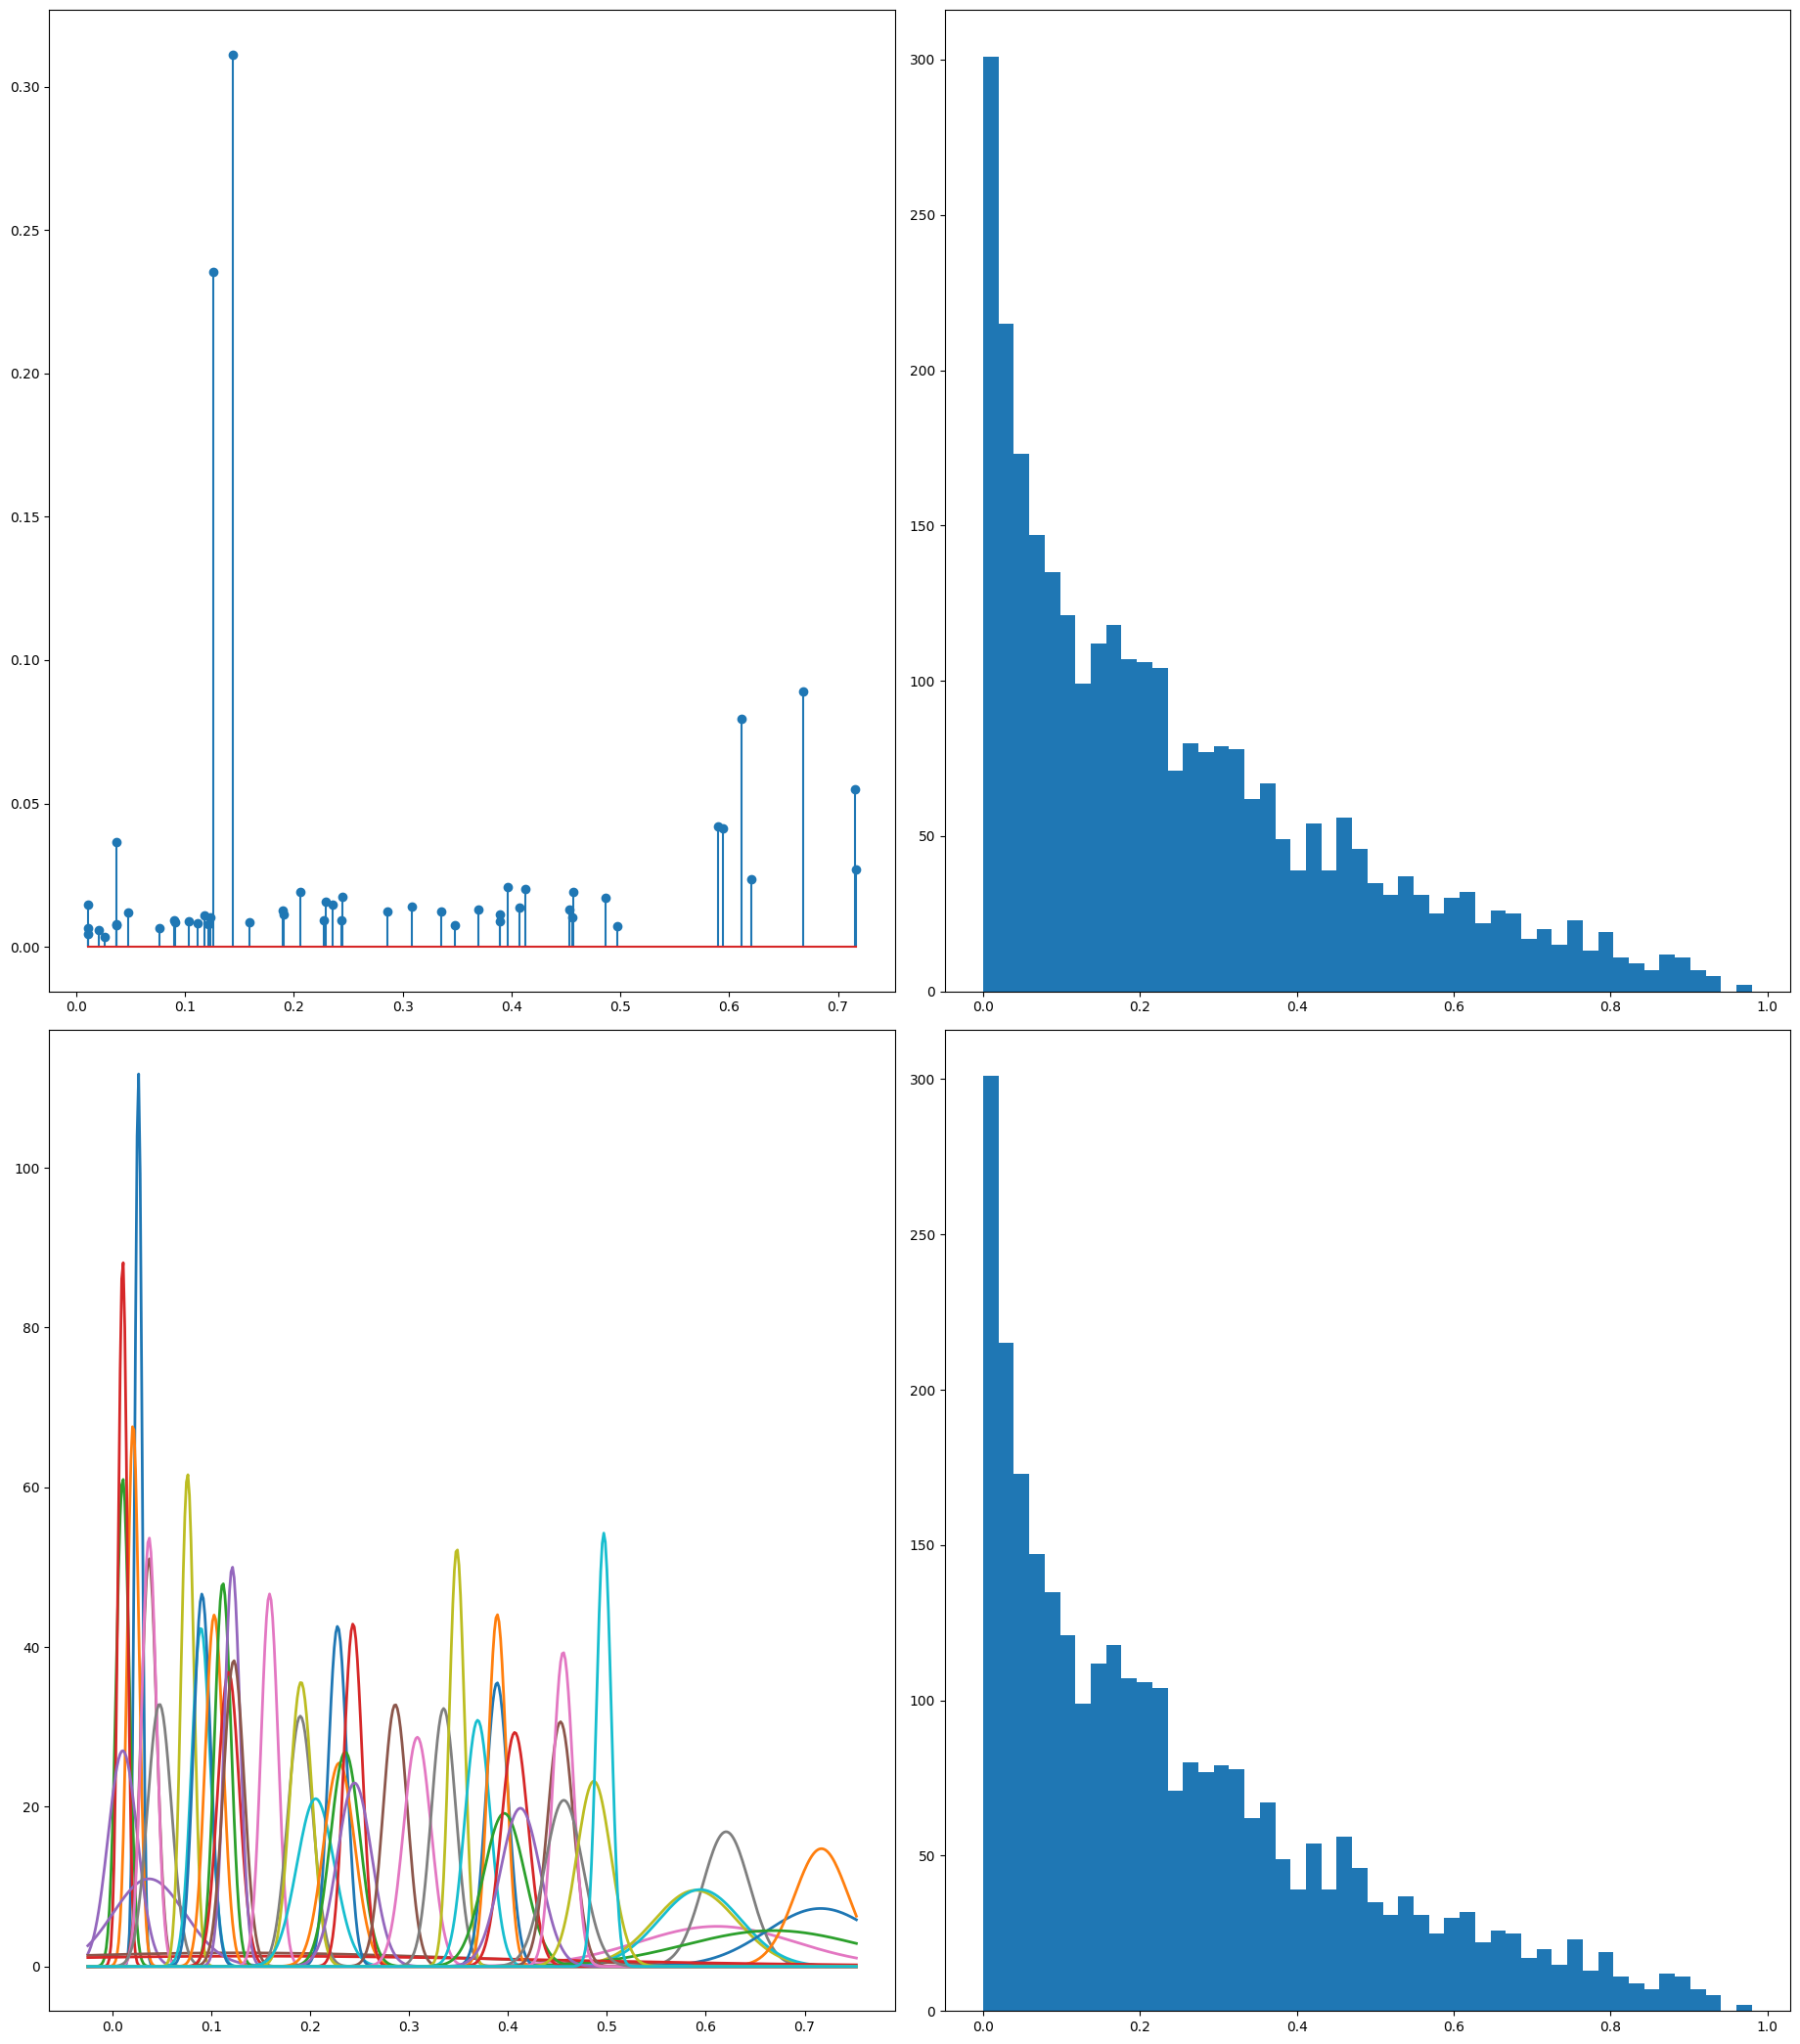

In [8]:
#spn.plot_som(som_1, True)
spn.plot_som(som_2, True)
spn.plot_hcm(correlation_matrix)
spn.plot_hcm(correlation_matrix, True)
spn.plot_som_comparison_to_data(som_2, df_power['y_data'].tolist())

In [10]:
errors = []

for i in range(100):
    test_data = df_power.sample()
    inti_test_value = test_data[['x_data', 'z_data']].iloc[0].to_numpy()
    result_test_value = test_data['y_data'].iloc[0]
    predicted = spice_net.decode(inti_test_value, decoder='bert-optimizer')
    errors.append(abs(predicted - result_test_value) / 2 * 100)
    print(f'Error: {errors[-1]:.6f},\t Predicted: {predicted:.6f},\t Actual: {result_test_value:.6f}')

print(f'Mean Error in % {np.mean(np.array(errors))}')
print(f'Median Error in % {np.median(np.array(errors))}')

start: 0.021125107901145183 end: 0.01066439312019252
Error: 35.675763,	 Predicted: 0.013280,	 Actual: 0.726795
start: 0.11762016306074573 end: 0.12289918541330895
Error: 0.804913,	 Predicted: 0.118427,	 Actual: 0.102329
start: 0.021125107901145183 end: 0.01066439312019252
Error: 26.187809,	 Predicted: 0.015094,	 Actual: 0.538851
start: 0.08966306016105456 end: 0.10314042730383612
Error: 2.591699,	 Predicted: 0.089663,	 Actual: 0.037829
start: 0.021125107901145183 end: 0.01066439312019252
Error: 36.061549,	 Predicted: 0.013280,	 Actual: 0.734511
start: 0.021125107901145183 end: 0.01066439312019252
Error: 0.200052,	 Predicted: 0.015952,	 Actual: 0.011951
start: 0.1908735220185177 end: 0.22783512861948266
Error: 4.365139,	 Predicted: 0.211664,	 Actual: 0.124362
start: 0.021125107901145183 end: 0.01066439312019252
Error: 32.108602,	 Predicted: 0.013280,	 Actual: 0.655452
start: 0.1908735220185177 end: 0.22783512861948266
Error: 0.316325,	 Predicted: 0.212684,	 Actual: 0.206358
start: 0.089